### Clustering

Same as classification, clustering is used to group data.

However,

- Classification refers to grouping labelled data.
- Clustering refers to grouping unlabelled data.

Scikit-learn provided education on various clustering methods:

https://scikit-learn.org/stable/modules/clustering.html

Nice reading!

### Impport Libraries and Data

In [ ]:
### Your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
df = pd.read_csv("https://drive.google.com/u/1/uc?id=1AW1J-QpOmctY8aVkw6kxvYBpk0otGZXb&export=download")
df

,Height,Weight,Group
0,69.44234,166.1346,B
1,66.07250,113.1841,C
2,72.95904,117.1612,A
3,68.71877,128.5218,C
4,76.01952,181.8577,B
...,...,...,...
74995,72.90698,122.5176,A
74996,71.61927,127.5175,A
74997,69.44838,137.7202,C
74998,73.91457,126.7841,A


<Axes: xlabel='Height', ylabel='Weight'>

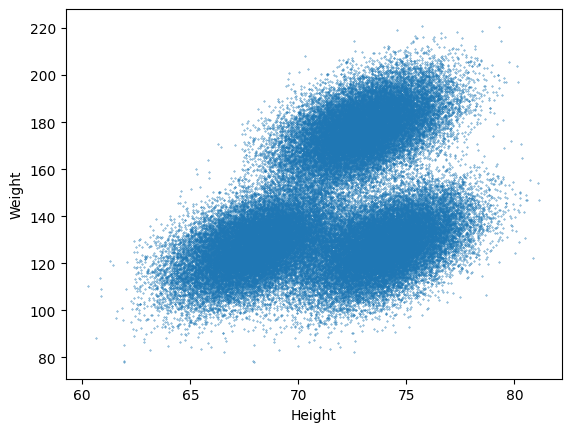

In [ ]:
df.plot.scatter("Height", "Weight", s= 0.1)

### 1. Kmeans

![](https://storage.googleapis.com/aihub-c2t-containers-public/release-0.2.0/kfp-components/oob_algorithm/kmeans/assets/kmeans.png)

Image from https://storage.googleapis.com/aihub-c2t-containers-public/release-0.2.0/kfp-components/oob_algorithm/kmeans/assets/kmeans.png

![](https://astrostatistics.psu.edu/su09/lecturenotes/image/kmall.png)

The algorithm of kmeans is simple:

1. Randomly pick n centroids
2. Group samples by their nearest centroids
3. Move the centroid to the center of the sample in that group
4. Repeat until the centroids do not move anymore

## Standardize the Data
When working with distance-based algorithms, like k-Means Clustering, we must normalize the data.
If we do not standardize the data, variables with different scaling will be weighted differently in the distance formula that is being optimized during training.

- create a new variable `X` that contains the values of column: `Height` and `Weight`.
- normalize the training and test data using the `StandardScaler()` from sklearn method from sklearn

In [ ]:
### Your code here

X =df[['Height', 'Weight']].values

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler(with_mean=False)

# Fit the scaler to your data and transform it
X_standardized = scaler.fit_transform(X)

## Using the elbow method to find the optimal number of clusters
We loop through a range of cluster numbers (from 1 to 10) and calculate the Within-Cluster Sum of Squares (WCSS) for each number of clusters.
We plot the WCSS values against the number of clusters to create an elbow plot.
Based on the elbow plot, we visually identify the "elbow" point, which suggests the optimal number of clusters. In this case, it's 4 clusters.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

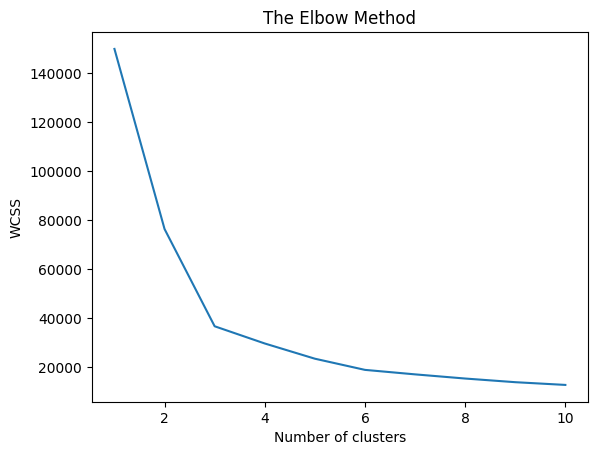

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_standardized)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Fitting and Evaluating the Model
For the first iteration, we will arbitrarily choose a `number of clusters` (referred to as k) of 3. We will create an instance of KMeans, define the number of clusters using the `n_clusters` attribute. We can then fit the model to the normalized training data using the `fit()` method.

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 0)
y_kmeans = kmeans.fit_predict(X_standardized)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## Visualising the clusters

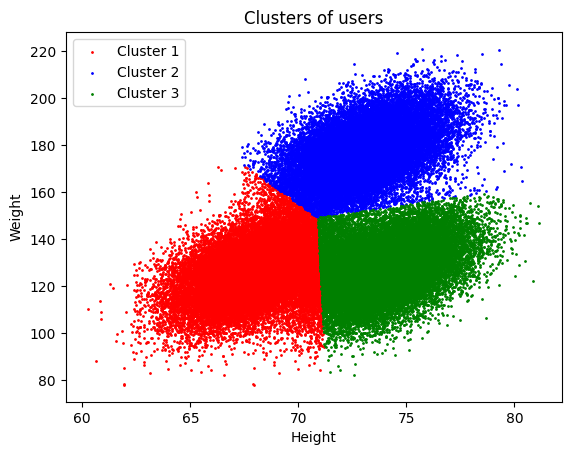

In [ ]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 1, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 1, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 1, c = 'green', label = 'Cluster 3')
plt.title('Clusters of users')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()

KMeans has limitation that it does not work well in all cases:

![](https://smorbieu.gitlab.io/images/clustering/kmeans.svg)

Image from https://smorbieu.gitlab.io/images/clustering/kmeans.svg